In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))

from src.charts.catch_up_inequality import create_catch_up_gap_width_chart
from src.charts.transition_problem import create_transition_problem_chart
from src.charts.unequal_distribution import create_unequal_distribution_chart
from src.loaders import initialise_gos_l_sheet, initialise_gos_sheet
from src.preparation.qilt import prepare_qilt_sheet
from src.transform.catch_up_inequality import (
    build_catch_up_gap_width_table,
    build_catch_up_levels_table,
)
from src.transform.transition_problem import build_transition_problem_table
from src.transform.unequal_distribution import build_unequal_distribution_table

In [2]:
# Data loading — workbook/sheet definitions
gos_aggregate_sheet = initialise_gos_sheet(21)  # GOS 21
gos_demographic_sheet = initialise_gos_sheet(8)  # GOS 8
gos_gender_sheet = initialise_gos_sheet(5)  # GOS 5
gos_l_aggregate_sheet = initialise_gos_l_sheet(3)  # GOS-L 3
gos_l_demographic_sheet = initialise_gos_l_sheet(160)  # GOS-L 160

In [3]:
# Data loading — prepare the QILT sheets used by the presentation charts
prepared_gos_aggregate_sheet = prepare_qilt_sheet(
    gos_aggregate_sheet.folder,
    gos_aggregate_sheet.file_name,
    gos_aggregate_sheet.sheet_name,
)
prepared_gos_demographic_sheet = prepare_qilt_sheet(
    gos_demographic_sheet.folder,
    gos_demographic_sheet.file_name,
    gos_demographic_sheet.sheet_name,
)
prepared_gos_gender_sheet = prepare_qilt_sheet(
    gos_gender_sheet.folder,
    gos_gender_sheet.file_name,
    gos_gender_sheet.sheet_name,
)
prepared_gos_l_aggregate_sheet = prepare_qilt_sheet(
    gos_l_aggregate_sheet.folder,
    gos_l_aggregate_sheet.file_name,
    gos_l_aggregate_sheet.sheet_name,
)
prepared_gos_l_demographic_sheet = prepare_qilt_sheet(
    gos_l_demographic_sheet.folder,
    gos_l_demographic_sheet.file_name,
    gos_l_demographic_sheet.sheet_name,
)

In [4]:
# Table building

# Report part 1 — There is a real transition problem
# Main presentation chart
# Answers: Is the graduate market actually worse right now at 4 months after graduation?
transition_problem_table = build_transition_problem_table(
    prepared_gos_aggregate_sheet, # GOS 21
    prepared_gos_l_aggregate_sheet, # GOS-L 3
)
transition_problem_table

,year,period_label,short_term_full_time_employment,short_term_overall_employment,short_term_labour_force_participation,medium_term_full_time_employment,medium_term_overall_employment,medium_term_labour_force_participation
0,2022,2022,78.5,88.3,92.4,91.5,93.9,92.2
1,2023,2023,79.0,88.9,92.5,91.7,93.8,92.7
2,2024,2024,74.0,86.9,92.6,91.1,93.3,92.7


In [5]:
# Report part 2 — It is not equally distributed
# Main presentation chart
# Answers: Which subgroup dimensions show the biggest short-term waiting gap in 2024?
unequal_distribution_table = build_unequal_distribution_table(
    prepared_gos_demographic_sheet, # GOS 8
    prepared_gos_gender_sheet, # GOS 5
)
unequal_distribution_table

,row_group,low_row_label,high_row_label,pair_label,comparison_available,availability_note,full_time_employment_low_value,full_time_employment_high_value,full_time_employment_gap,full_time_employment_availability_note,overall_employment_low_value,overall_employment_high_value,overall_employment_gap,overall_employment_availability_note,labour_force_participation_low_value,labour_force_participation_high_value,labour_force_participation_gap,labour_force_participation_availability_note,row_group_order
0,Home language,Language other than English,English,Other vs English,True,None,58.1,74.5,16.4,None,73.6,87.3,13.7,None,88.5,92.7,4.2,None,0
1,Study mode,Internal/Mixed study mode,External study mode,Internal/Mixed vs External,True,None,71.9,81.2,9.3,None,86.2,89.5,3.3,None,92.8,92.0,-0.8,None,1
2,Locality,Metro,Regional/Remote,Metro vs Regional/Remote,True,None,71.7,80.6,8.9,None,86.1,89.9,3.8,None,92.7,93.2,0.5,None,2
3,Indigenous,Non-Indigenous,Indigenous,Non-Indigenous vs Indigenous,True,None,73.9,82.7,8.8,None,86.9,88.8,1.9,None,92.6,91.5,-1.1,None,3
4,Disability,Disability reported,No disability reported,Disability reported vs No disability reported,True,None,66.8,75.0,8.2,None,82.9,87.4,4.5,None,89.8,93.0,3.2,None,4
5,Age group,30 years or under,Over 30 years,30 and under vs Over 30,True,None,72.4,80.1,7.7,None,86.5,88.4,1.9,None,93.3,90.4,-2.9,None,5
6,Gender,Male,Female,Male vs Female,True,None,72.7,74.9,2.2,None,84.7,88.0,3.3,None,92.0,92.9,0.9,None,6
7,First in family,Not first in family,First in family,Not first in family vs First in family,True,None,73.4,75.1,1.7,None,86.7,87.9,1.2,None,92.8,93.4,0.6,None,7
8,Socio-economic status,High,Low,High vs Low,True,None,73.5,73.8,0.3,None,86.7,86.4,-0.3,None,92.2,93.1,0.9,None,8


In [6]:
# Report part 3 — The later picture may improve, but not necessarily equally
# Main presentation chart
# Answers: Did the short-term inequality gap shrink by 3 years after graduation?
catch_up_levels_table = build_catch_up_levels_table(
    prepared_gos_demographic_sheet, # GOS 8
    prepared_gos_l_demographic_sheet, # GOS-L 160
)
gap_width_table = build_catch_up_gap_width_table(
    prepared_gos_demographic_sheet, # GOS 8
    prepared_gos_l_demographic_sheet, # GOS-L 160
)
gap_width_table

,row_group,outcome_key,short_term_gap,medium_term_gap,gap_closure,short_term_low_label,short_term_high_label,medium_term_low_label,medium_term_high_label,row_group_order,reference_low_label,reference_high_label,pair_label
0,Home language,full_time_employment,16.4,0.8,15.6,Language other than English,English,Language other than English,English,0,Language other than English,English,Other vs English
1,Home language,overall_employment,13.7,2.1,11.6,Language other than English,English,Language other than English,English,0,Language other than English,English,Other vs English
2,Home language,labour_force_participation,4.2,4.4,-0.2,Language other than English,English,Language other than English,English,0,Language other than English,English,Other vs English
3,Study mode,full_time_employment,9.3,0.5,8.8,Internal/Mixed study mode,External study mode,Internal/Mixed study mode,External study mode,1,Internal/Mixed study mode,External study mode,Internal/Mixed vs External
4,Study mode,overall_employment,3.3,1.0,2.3,Internal/Mixed study mode,External study mode,Internal/Mixed study mode,External study mode,1,Internal/Mixed study mode,External study mode,Internal/Mixed vs External
5,Study mode,labour_force_participation,0.8,1.7,-0.9,External study mode,Internal/Mixed study mode,External study mode,Internal/Mixed study mode,1,Internal/Mixed study mode,External study mode,Internal/Mixed vs External
6,Locality,full_time_employment,8.9,0.5,8.4,Metro,Regional/Remote,Metro,Regional/Remote,2,Metro,Regional/Remote,Metro vs Regional/Remote
7,Locality,overall_employment,3.8,0.7,3.1,Metro,Regional/Remote,Metro,Regional/Remote,2,Metro,Regional/Remote,Metro vs Regional/Remote
8,Locality,labour_force_participation,0.5,0.6,-0.1,Metro,Regional/Remote,Regional/Remote,Metro,2,Metro,Regional/Remote,Metro vs Regional/Remote
9,Indigenous,full_time_employment,8.8,0.2,8.6,Non-Indigenous,Indigenous,Indigenous,Non-Indigenous,3,Non-Indigenous,Indigenous,Non-Indigenous vs Indigenous


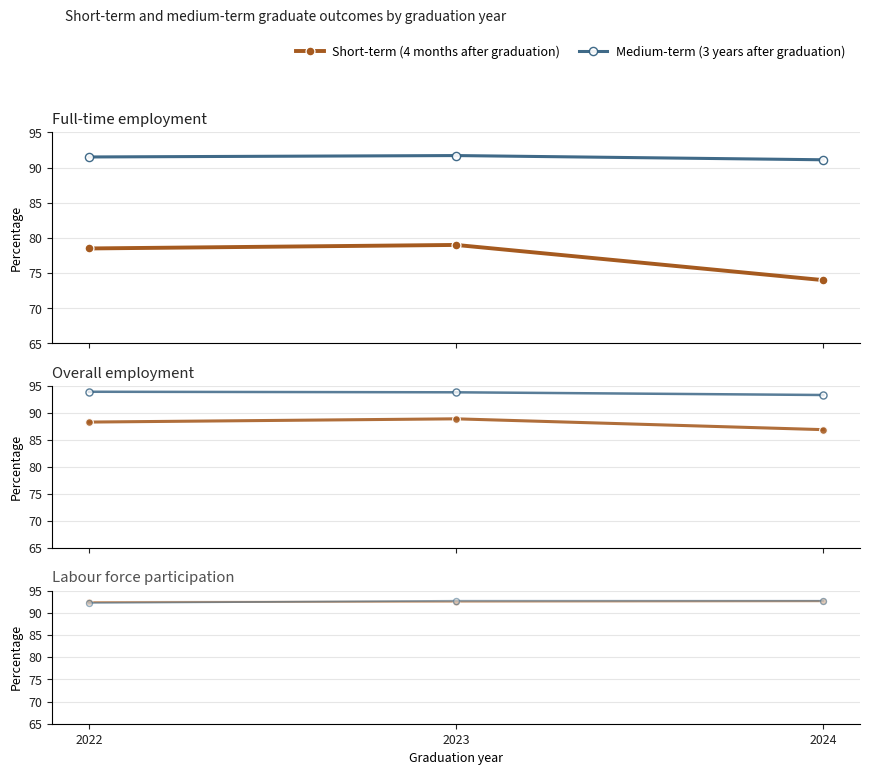

In [7]:
# Main chart generation

# Report part 1 — There is a real transition problem
# Main presentation chart
# Answers: Is the graduate market actually worse right now?
transition_problem_figure = create_transition_problem_chart(transition_problem_table)
transition_problem_figure

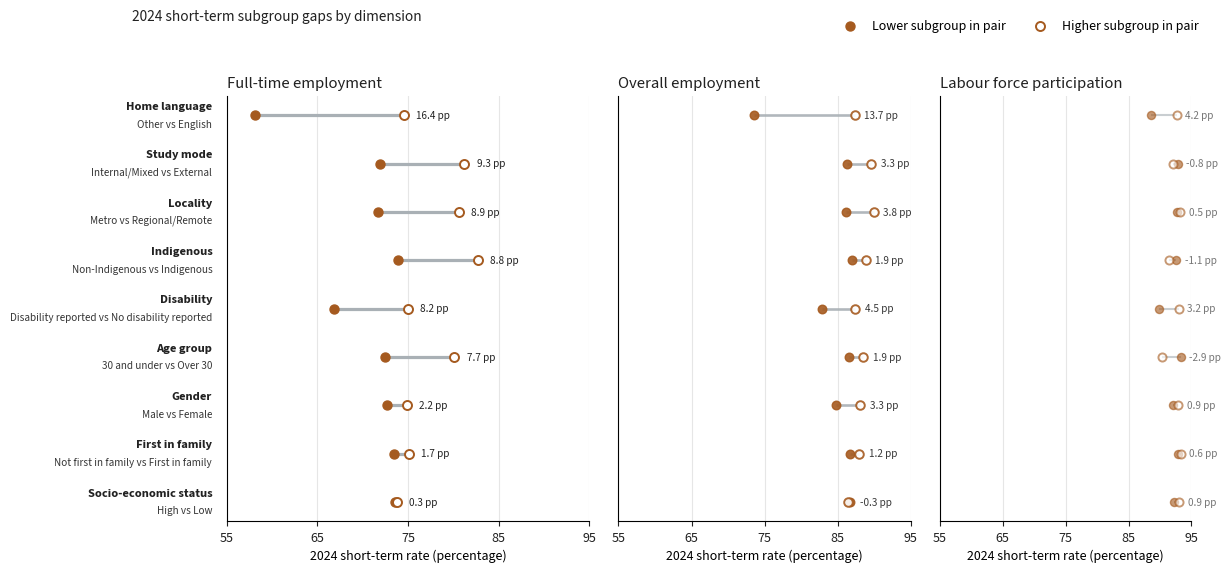

In [8]:
# Report part 2 — It is not equally distributed
# Main presentation chart
# Answers: Who is waiting longer in the 2024 short-term graduate market?
unequal_distribution_figure = create_unequal_distribution_chart(
    unequal_distribution_table,
)
unequal_distribution_figure

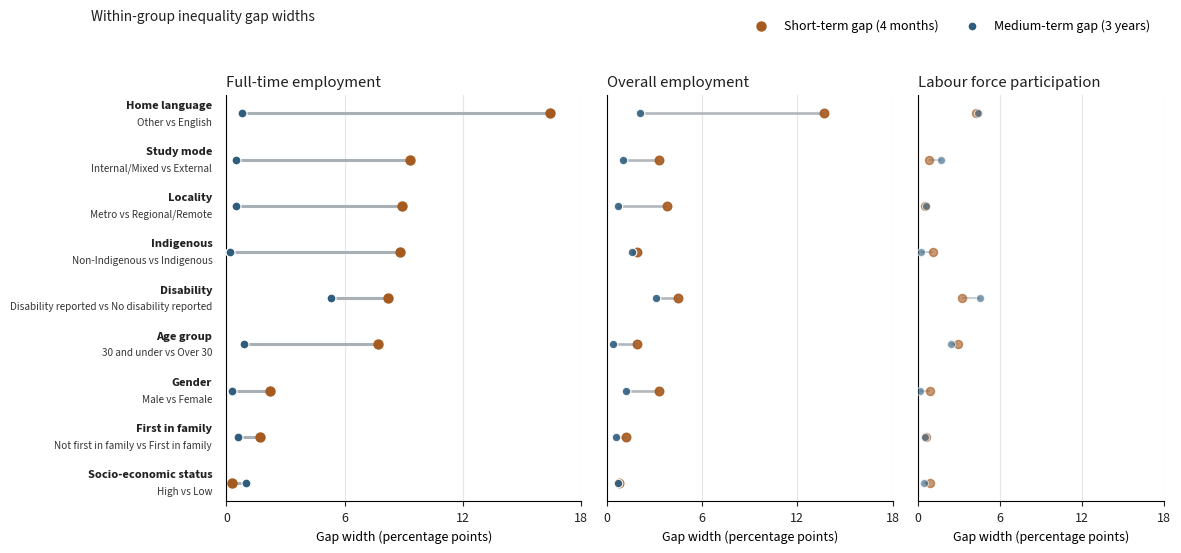

In [9]:
# Report part 3 — The later picture may improve, but not necessarily equally
# Main presentation chart
# Answers: Which short-term subgroup gaps close by 3 years after graduation, and which do not?
gap_width_figure = create_catch_up_gap_width_chart(gap_width_table)
gap_width_figure